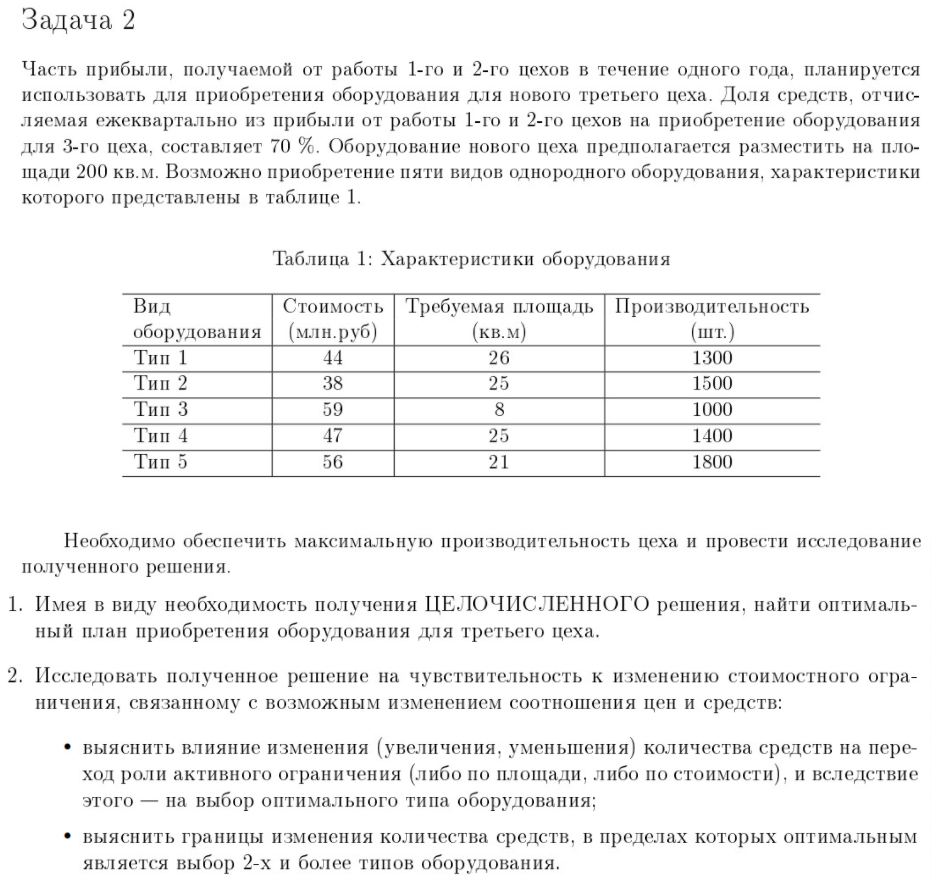

Постановка задачи.

Требуется определить оптимальный план приобретения оборудования для третьего цеха.

Из 1 задачи мы знаем прибыль от цехов за год - 653 млн руб. 70% от прибыли тратится на приобретение оборудования для 3 цеха. Тогда

Бюджет = 653*0.7 = 457.1 ~= 457 млн руб (округление вниз)

Площадь = 200 кв.м

Необходимо закупить разное оборудование таким образом, чтобы не превысить бюджет, площадь и при этом максимизировать производительность.

Формализация задачи.
Пусть:

x1 - количество оборудования типа 1.

x2 - количество оборудования типа 2.

x3 - количество оборудования типа 3.

x4 - количество оборудования типа 4.

x5 - количество оборудования типа 5.

При этом xi >= 0 для i=1,2,3,4,5

Целевая функция F.

F = 1300x1 + 1500x2 + 1000x3 + 1400x4 + 1800x5 -> max

Ограничение по бюджету.

44x1 + 38x2 + 59x3 + 47x4 + 56x5 <= 457

Ограничение по площади.

26x1 + 25x2 + 8x3 + 25x4 + 21x5 <= 200

Полный перебор (naive solution)

In [4]:
import time

start = time.perf_counter()
best_value = 0
best_plan = []
best_cost = 0
best_area = 0
for x1 in range(0, 10):
    for x2 in range(0, 10):
        for x3 in range(0, 10):
            for x4 in range(0, 10):
                for x5 in range(0, 10):

                    cost = 44*x1 + 38*x2 + 59*x3 + 47*x4 + 56*x5
                    area = 26*x1 + 25*x2 + 8*x3 + 25*x4 + 21*x5

                    if cost <= 457 and area <= 200:
                        value = (1300*x1 + 1500*x2 +
                                 1000*x3 + 1400*x4 + 1800*x5)

                        if value > best_value:
                            best_value = value
                            best_plan = [x1, x2, x3, x4, x5]
                            best_area=area
                            best_cost=cost

print("Оптимальный план:")
for i in range(len(best_plan)):
    print(f"x{i} = ", round(best_plan[i]))
print("Максимальная производительность =", best_value)
print("Стоимость = ", best_cost)
print("Занятая площадь =", best_area)
end = time.perf_counter()
bruteforce_time = end - start
print("Время решения перебором:", round(bruteforce_time*1000, 3), "мс")

Оптимальный план:
x0 =  0
x1 =  3
x2 =  1
x3 =  0
x4 =  5
Максимальная производительность = 14500
Стоимость =  453
Занятая площадь = 188
Время решения перебором: 37.835 мс


In [6]:
import pulp

start = time.perf_counter()
F = pulp.LpProblem("Производительность", pulp.LpMaximize)

x1 = pulp.LpVariable('x1', lowBound=0, cat='Integer')
x2 = pulp.LpVariable('x2', lowBound=0, cat='Integer')
x3 = pulp.LpVariable('x3', lowBound=0, cat='Integer')
x4 = pulp.LpVariable('x4', lowBound=0, cat='Integer')
x5 = pulp.LpVariable('x5', lowBound=0, cat='Integer')

F += 1300*x1 + 1500*x2 + 1000*x3 + 1400*x4 + 1800*x5
F += 44*x1 + 38*x2 + 59*x3 + 47*x4 + 56*x5 <= 457
F += 26*x1 + 25*x2 + 8*x3 + 25*x4 + 21*x5 <= 200
F.solve()

print("Оптимальный план:")
print("x1 =", round(x1.value()))
print("x2 =", round(x2.value()))
print("x3 =", round(x3.value()))
print("x4 =", round(x4.value()))
print("x5 =", round(x5.value()))

print("Максимальная производительность =", round(pulp.value(F.objective)))
end = time.perf_counter()
pulp_time = end - start
print("Время решения pulp:", round(pulp_time*1000, 3), "мс")

Оптимальный план:
x1 = 0
x2 = 3
x3 = 1
x4 = 0
x5 = 5
Максимальная производительность = 14500
Время решения pulp: 51.243 мс


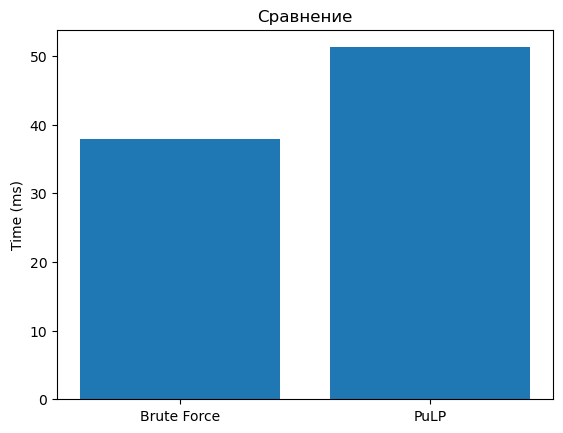

In [7]:
import matplotlib.pyplot as plt

methods = ["Brute Force", "PuLP"]
times = [bruteforce_time*1000, pulp_time*1000]

plt.figure()
plt.bar(methods, times)
plt.title("Сравнение")
plt.ylabel("Time (ms)")
plt.show()